In [1]:
import sys
sys.path.append('..')  # pour importer portfolio_analytics depuis la racine
%load_ext autoreload
%autoreload 2
%matplotlib inline
import numpy as np
import pandas as pd
import portfolio_analytics as erk

import ipywidgets as widgets
from IPython.display import display, clear_output



## Short rate vs Annualized 

In [2]:
1 + 1*1

2

In [3]:
1 + 1*0.5 + (1 + 1*0.5)*.5

2.25

In [4]:
1 + (1)*0.25+(1 + (1)*0.25)*.25+(1 + (1)*0.25+(1 + (1)*0.25)*.25)*.25 + (1 + (1)*0.25+(1 + (1)*0.25)*.25+(1 + (1)*0.25+(1 + (1)*0.25)*.25)*.25)*0.25

2.44140625

In [5]:
(1+1/10000)**10000

2.7181459268249255

In [6]:
def inst_to_ann(r):
    ''' convert short rate into anuualized rate'''
    return np.expm1(r)
def ann_to_inst(r):
    """ convert ann into short rate"""
    return np.log1p(r)

In [7]:
def cir(n_years= 10, n_scenarios=1, a=0.05, b=0.03, sigma=0.05, 
        steps_per_year=12, r_0=None):
    """ 
    implements the CIR model for interest Rate
    """
    if r_0 is None:r_0 = b
    r_0 = ann_to_inst(r_0)
    dt = 1/steps_per_year

    num_steps = int(n_years*steps_per_year)+1
    shock = np.random.normal(0, scale=np.sqrt(dt), size=(num_steps, n_scenarios))
    rates = np.empty_like(shock)
    rates[0] = r_0
    for step in range(1, num_steps):
        r_t = rates[step-1]
        d_r_t = a*(b-r_t)*dt +sigma*np.sqrt(r_t)*shock[step]
        rates[step] = abs(r_t + d_r_t)
    return pd.DataFrame(data=inst_to_ann(rates), index=range(num_steps))

In [8]:
%matplotlib inline

<Axes: >

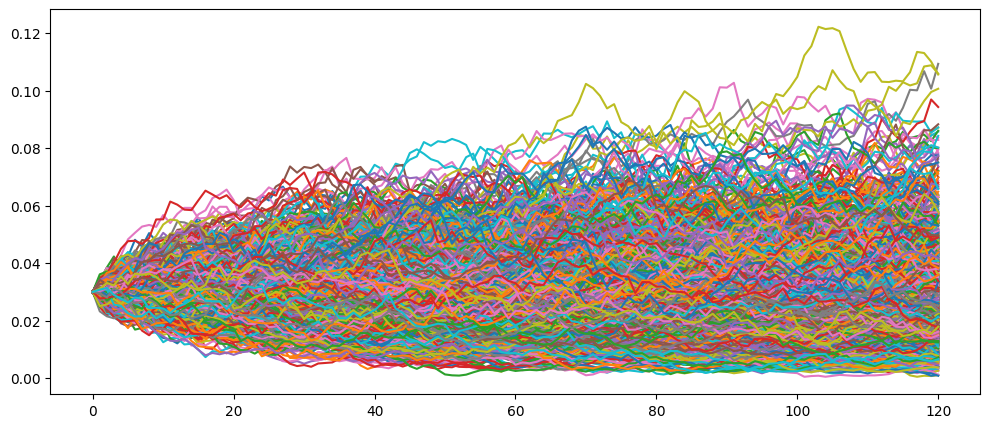

In [9]:
 cir(n_scenarios=1000, sigma=0.04).plot(figsize=(12,5), legend=0)

In [10]:
import math
def cir(n_years = 10, n_scenarios=1, a=0.05, b=0.03, sigma=0.05, steps_per_year=12, r_0=None):
    """
    Generate random interest rate evolution over time using the CIR model
    b and r_0 are assumed to be the annualized rates, not the short rate
    and the returned values are the annualized rates as well
    """
    if r_0 is None: r_0 = b 
    r_0 = ann_to_inst(r_0)
    dt = 1/steps_per_year
    num_steps = int(n_years*steps_per_year) + 1 # because n_years might be a float
    
    shock = np.random.normal(0, scale=np.sqrt(dt), size=(num_steps, n_scenarios))
    rates = np.empty_like(shock)
    rates[0] = r_0

    ## For Price Generation
    h = math.sqrt(a**2 + 2*sigma**2)
    prices = np.empty_like(shock)
    ####

    def price(ttm, r):
        _A = ((2*h*math.exp((h+a)*ttm/2))/(2*h+(h+a)*(math.exp(h*ttm)-1)))**(2*a*b/sigma**2)
        _B = (2*(math.exp(h*ttm)-1))/(2*h + (h+a)*(math.exp(h*ttm)-1))
        _P = _A*np.exp(-_B*r)
        return _P
    prices[0] = price(n_years, r_0)
    ####
    
    for step in range(1, num_steps):
        r_t = rates[step-1]
        d_r_t = a*(b-r_t)*dt + sigma*np.sqrt(r_t)*shock[step]
        rates[step] = abs(r_t + d_r_t)
        # generate prices at time t as well ...
        prices[step] = price(n_years-step*dt, rates[step])

    rates = pd.DataFrame(data=inst_to_ann(rates), index=range(num_steps))
    ### for prices
    prices = pd.DataFrame(data=prices, index=range(num_steps))
    ###
    return rates, prices


In [11]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

out = widgets.Output()

def show_cir_prices(r_0=0.03, a=0.5, b=0.03, sigma=0.05, n_scenarios=5):
    out.clear_output(wait=True)
    with out:
        fig, ax = plt.subplots(figsize=(12, 5))
        cir(r_0=r_0, a=a, b=b, sigma=sigma, n_scenarios=n_scenarios)[1].plot(
            legend=False, ax=ax
        )
        plt.show()

# Sliders définis manuellement
w_r0      = widgets.FloatSlider(value=0.03, min=0,    max=0.15, step=0.01,  description='r_0')
w_a       = widgets.FloatSlider(value=0.5,  min=0,    max=1,    step=0.1,   description='a')
w_b       = widgets.FloatSlider(value=0.03, min=0,    max=0.15, step=0.01,  description='b')
w_sigma   = widgets.FloatSlider(value=0.05, min=0,    max=0.1,  step=0.01,  description='sigma')
w_n       = widgets.IntSlider(  value=5,    min=1,    max=100,  step=1,     description='n_scenarios')

def on_change(_):
    show_cir_prices(w_r0.value, w_a.value, w_b.value, w_sigma.value, w_n.value)

for w in [w_r0, w_a, w_b, w_sigma, w_n]:
    w.observe(on_change, names='value')

# Affichage initial
show_cir_prices()

display(widgets.VBox([w_r0, w_a, w_b, w_sigma, w_n, out]))

In [12]:
# my starting asset value today aka cash in hand
a_0 = 0.75
# simulate the next 10 years
rates, bond_prices = erk.cir(r_0=0.03, b=0.03, n_scenarios=10)
# liabilities are going to change over time to match the payoff of the ZCB
liabilities = bond_prices
# today's zero coupon bond price is the present value of 1 dollar in 10 years
zc_0 = erk.pv(pd.Series(data=[1], index=[10]), 0.03)
# I can put my money in a zero coupon bond at today's price
n_bonds = a_0/zc_0
# and my asset value will grow based on the bond prices
av_zc_bonds = n_bonds*bond_prices
# how about if I invest in cash? It will grow at some rate of interest
av_cash = a_0*(rates/12+1).cumprod()

<Axes: >

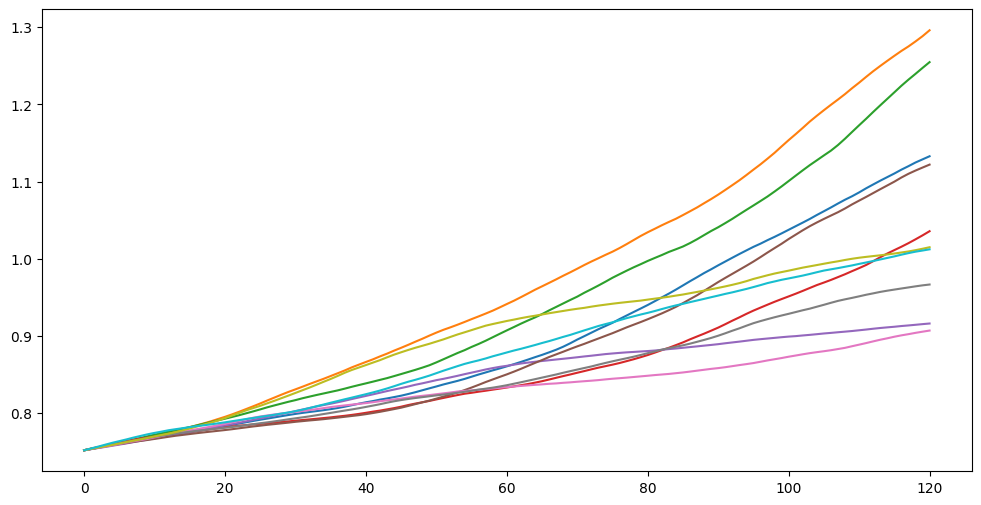

In [14]:
av_cash.plot(legend=False, figsize=(12,6))

<Axes: >

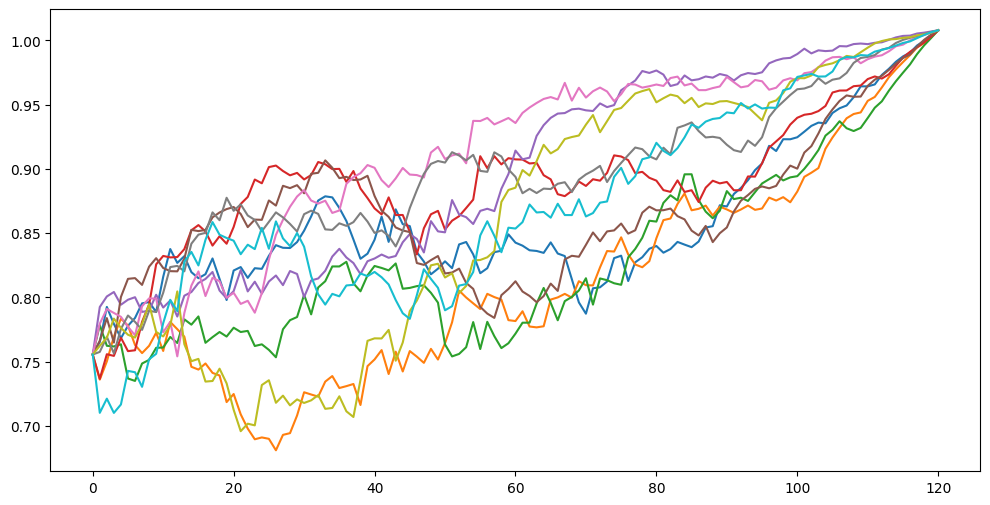

In [15]:
av_zc_bonds.plot(legend=False, figsize=(12,6))

<Axes: title={'center': 'Returns using ZC Bonds (10 scenarios)'}>

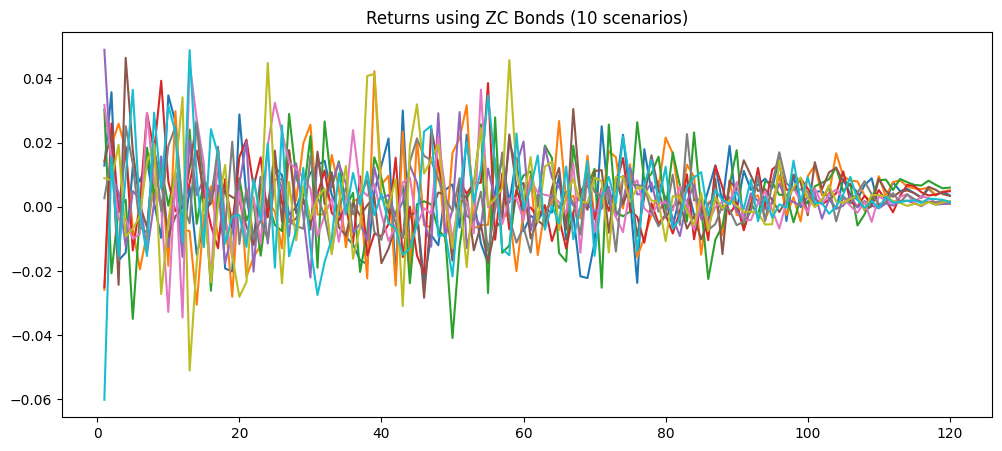

In [ ]:
av_zc_bonds.pct_change().plot(title='Returns using ZC Bonds (10 scenarios)', legend=False, figsize=(12,5))

<Axes: title={'center': 'Returns using ZC Bonds (10 scenarios)'}>

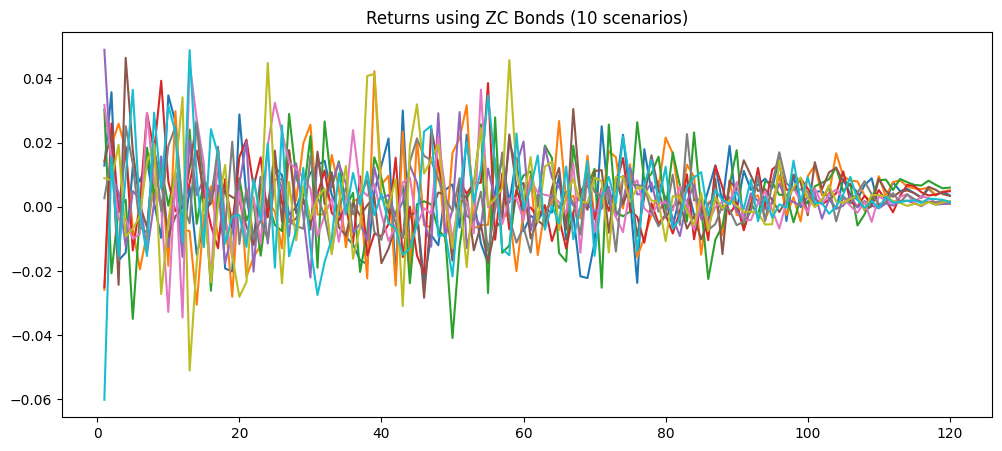

In [18]:
av_zc_bonds.pct_change().plot(title='Returns using ZC Bonds (10 scenarios)', legend=False, figsize=(12,5))

In [19]:
a_0
rates, bondes_prices = cir(n_scenarios=1000, r_0=0.03, b=0.03)
liabilities = bond_prices
zc_0 = erk.pv(zcbond_10, 0.03)
n_bonds = a_0/zc_0
av_zc_bonds = n_bonds*bond_prices
av_cash = a_0*(rates/12+1).cumprod()

NameError: name 'zcbond_10' is not defined